# Generative Adversarial Networks with applications in microstructure modelling: Follow-up project

### 2025 CMIT Summer Research Internship Programme, University of Liverpool, August-September 2025


#### Maciej Buze, Lancaster University

<br><br><br>

$\,$ | $\,$
- | - 
<img src="./figures/MARS.png" alt="drawing" width="550"/> | <img src="./figures/lancaster.jpg" alt="drawing" width="700"/>

## Instructions

Thank you for choosing this topic as the follow-up project. Some details:
- The project is designed to be about one week of work
- A short 10-15 mins (group) presentation to be given in the week 15-19 September with a summary of activities undertaken.
- Two basic tasks (details below):
  1. Redo the full training pipeline of the machine learning model presented in the course "from scratch" by (a) generating a new and more detailed and varied `PyAPD` data set; (b) running a full and optimised training routine.
  2. Explore advanced image processing tools in Python to "post-process" the outputs of our machine learning model to take us closer to realistic images of microstructure.

You are invited to explore all or some aspects of what is outlined below. The tasks are pretty open ended and can be tackled somewhat superficially or in great depth and can be split among group members. 

## (1A) More versatile data set

In the course, the training of the machine learning model relied upon a pre-prepared data set available at 

https://github.com/mbuze/GAN_microstructures_Summer_School/raw/main/data/apd_data.zip

The data set consisted of 14164 images, each contaning 76x76 greyscale pixels. Each image was generated using `PyAPD` library, roughly via the following code:

In [1]:
import PyAPD
i = 50
apd1 = PyAPD.apd_system(N=15,
                        ani_thres=0.5,
                        seed = i,
                        pixel_params = (76,76)
                       )
apd1.check_optimality()
apd1.Lloyds_algorithm(K=10)
apd1.find_optimal_W()

[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode
Precision loss detected!
Percentage error =  101.26358032226562
Lloyds iteration: 0
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.5369223356246948
Lloyds iteration: 1
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7615461349487305
Lloyds iteration: 2
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.5369223356246948
Lloyds iteration: 3
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.5018524527549744
Lloyds iteration: 4
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7966160774230957
Lloyds iteration: 5
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7966160774230957
Lloyds iteration: 6
Optimality condition successfully overwritten.
The

In particular, we held some parameters fixed throughout: number of grains `N=15`, anisotropy threshold `ani_thres = 0.5`, we always had 76x76 pixels (`pixel_params`) and `target_masses` of each grain was kept at `1/N`:

In [2]:
apd1.target_masses

tensor([0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667,
        0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667])

For the new data set let us for each sample:
- still keep the number of pixels fixed, but increase it to 100x100
- randomly sample `ani_thres` uniformly from between 0.05 and 0.6
- randomly sample `N` categorically distributed between 5 and 35
- randomly `target_masses` from lognormal distribution, making sure that the sum of target masses sums up to 1.
- Create a sample of $30,000$ such images.

Here is some code outlining how something similar can be done (if more help is needed, get in touch!) [NOTE: not everything is exactly correct here, make sure you adjust it properly]


In [3]:
import numpy as np

# Categorical:
N_min, N_max = 10, 15  # range for categorical (integer) samples

# Generate categorical samples (integers)
categorical_sample = np.random.randint(N_min, N_max + 1, size=1)

# Uniform
a, b = 0.5, 0.7 # interval for uniform distribution
# Generate uniform samples
uniform_sample = np.random.uniform(a, b, size=categorical_sample[0])

# Lognormal
mean = 0.0   # mu of underlying normal
sigma = 0.5  # sigma of underlying normal
loc = 0.5    # shift to avoid very small grains
size = categorical_sample[0]

lognormal_sample = np.random.lognormal(mean, sigma, size=size) + loc

lognormal_sample /= lognormal_sample.sum() # rescale so that it adds up to 1

Some further guidance can be found here in the `example_usage` notebook from `PyAPD`:

https://nbviewer.org/github/mbuze/PyAPD/blob/main/notebooks/tutorials/example_usage.ipynb?flush_cache=true

Other details can be found in the first notebook from the course:

https://github.com/mbuze/GAN_microstructure_modelling/blob/main/notebooks/GANs_microstructure_modelling_1.ipynb

and in the notebook devoted to the generation of the original data set:

https://github.com/mbuze/GAN_microstructure_modelling/blob/main/notebooks/generating_pyapd_data.ipynb

## (1B) Running the training routine



The second objective of the project is for you to run the full training of the machine learning model, based on the new data set. This should ideally consist of first a prototyping phase, where you try to tinker with the many hyperparameters of the setup:
- dimensionality of the input Gaussian distribution,
- sizes of layers,
- depth of layers,
- batch sizes
- learning rate of the ADAM optimisers (naive specific idea to explore: it looks like the generator remains "underpowered" after say 10-20 epoch, maybe increase the learning rate for it after first 10-20 epochs? Doing it earlier might run the risk of not giving discriminator enough time to become good at discriminating)

Ultimately, a full learning procedure should probably run for anything between 50 and 300 epochs, and since we are using the original GAN formulation, we should always check if the learning still makes sense and we do not observe some sort of collapse. In any case, this should take several hours of runtime on your laptops. The task is to do the whole procedure.

## (2) Postprocessing 

While the machine learning model will learn to create images that look (somewhat) like microstructure of polycrystal materials, it is unlikely that it will ever reliably learn to create very sharp boundaries between grains. Outputs from the generator are likely to be quite blurry. It doesn't mean that the model is bad though, but rather points to a need for some post-processing of the images generated by the trained generator. In the final more creative task, you are asked to do precisely that by leveraging powerful imagining algorithms available in Python. 

Specfically, the idea of this task is to use tools available in

https://scikit-image.org/

which can be installed with `pip install scikit-image` as detailed here: https://pypi.org/project/scikit-image/



In [4]:
import skimage as ski
import matplotlib.pyplot as plt

Here is an example of such analysis for an image generated by `PyAPD`:

In [5]:
img = apd1.assemble_apd().reshape(apd1.pixel_params).cpu().detach().numpy()

Suppose we did not know the grain assignment of each pixels in this image (of course for `PyAPD` images we do know it, but for outputs of the GAN machine learning model we wouldn't!):

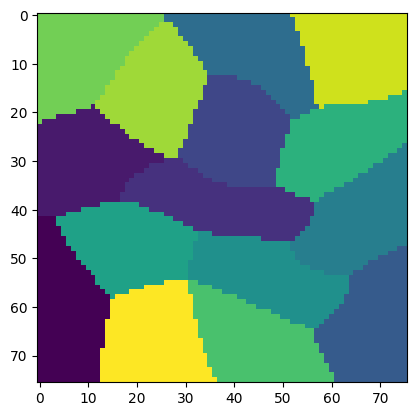

In [6]:
plt.imshow(img)

### Finding edges via Sobel gradient

We can try to identify the edges between grains by running the following:

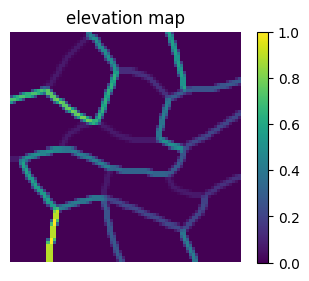

In [7]:
elevation_map = ski.filters.sobel(img)
elevation_map = elevation_map / elevation_map.max() 
#elevation_map[elevation_map > 1e-2] = 1.0
fig, ax = plt.subplots(figsize=(4, 3))
cc = ax.imshow(elevation_map)#, cmap=plt.cm.gray)
fig.colorbar(cc, ax=ax)
ax.set_title('elevation map')
ax.set_axis_off()

And the following code will now isolate each connected component as a separate grain:

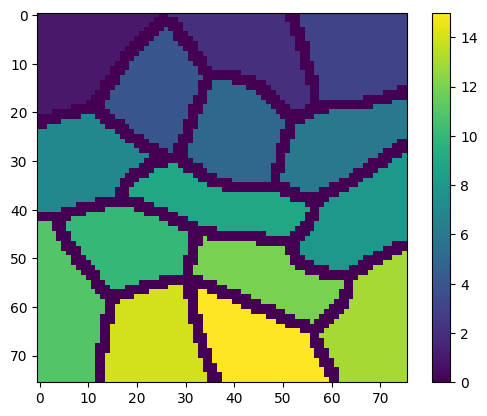

In [8]:
labeled=ski.measure.label(elevation_map==0)
#labeled[labeled==labeled[0,0]]=0
plt.imshow(labeled)
plt.colorbar()
plt.show()

and just like that, we have recovered pretty much perfect information about each grain (apart from rather thick boundaries).

### Felzenszwalb segmentation algorithm
Another method is to use the Felzenszwalb segmentation algorithm: 

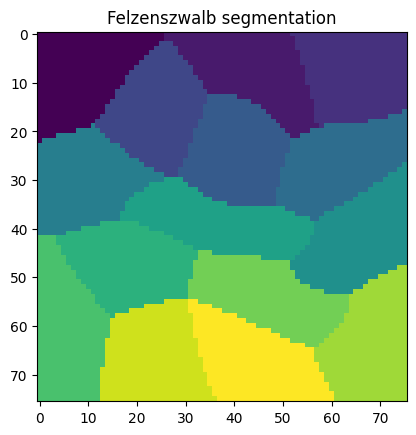

In [9]:
from skimage.segmentation import felzenszwalb
img2 = img / img.max()
seg = felzenszwalb(img2, scale=1.0, sigma=0.2, min_size=10)
plt.imshow(seg)
plt.title("Felzenszwalb segmentation")
plt.show()

### Applying it to images from the Generator

At the end of the learning for the generator, we can generate new (hopefully realistic) but blurry images by running:

```
new_input = torch.randn(bs, g_dim, device=device)

img = G(new_input)[11,0,:,:].detach().numpy() # isolate one image from the batch
```

Play around with the two algorithms I highlighted (or indeed any other available via `scikit-image`) to try to postprocess the images to make sure they create images of grains with sharp boundaries. 